# Assignment 1 
### Submitted by: 
Aantriksh Sood <br>
Batch 1 <br>
500124259

In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1: Dataset Overview

In [ ]:
df = pd.read_csv('Real estate.csv')
print("Header information")
print(df.head())
print("\nColumn information:")
print(df.info())

# Display column names and data types
dataset_info = df.dtypes

# Check for missing and duplicate values
missing_values = df.isnull().sum()
duplicate_values = df.duplicated().sum()

print(dataset_info, missing_values, duplicate_values)
for column in df.columns:
    print(f"\nUnique values in {column}:")
    print(df[column].value_counts().head())
    print(f"Total unique values: {df[column].nunique()}")

Header information
   No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3     24.98

### Task 2: Statistical Summary

Statistical summary of numerical columns:
               No  X1 transaction date  X2 house age  \
count  407.000000           407.000000    407.000000   
mean   207.906634          2013.146211     17.638329   
std    119.606544             0.281490     11.423157   
min      1.000000          2012.667000      0.000000   
5%      22.300000          2012.667000      1.100000   
25%    104.500000          2012.917000      8.900000   
50%    207.000000          2013.167000     16.100000   
75%    311.500000          2013.417000     27.800000   
95%    393.700000          2013.583000     37.770000   
max    414.000000          2013.583000     43.800000   

       X3 distance to the nearest MRT station  \
count                              407.000000   
mean                              1017.646541   
std                               1134.448058   
min                                 23.382840   
5%                                  90.456060   
25%                                289.324800  

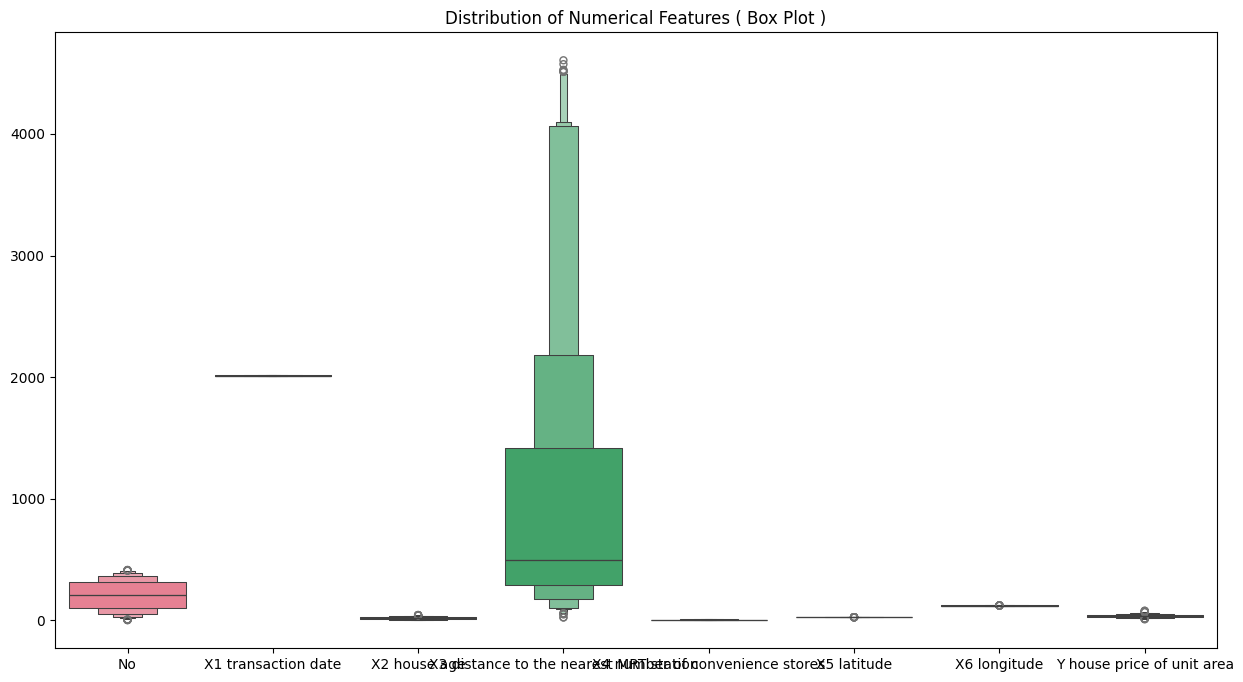

In [28]:
print("Statistical summary of numerical columns:")
stats_df = df.describe(include='all', percentiles=[.05, .25, .5, .75, .95])
print(stats_df)
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    print(f"\nAdditional statistics for {col}:")
    print(f"Skewness: {df[col].skew():.3f}")
    print(f"Variation coeffecient: {(df[col].std() / df[col].mean() * 100):.2f}%")

# Create detailed box plots with points
plt.figure(figsize=(15, 8))
sns.boxenplot(data=df[numerical_cols])
plt.title('Distribution of Numerical Features ( Box Plot )')
plt.show()


### Task 3: Data Cleaning

In [20]:
# Check for missing values (already confirmed none exist)
missing_check = df.isnull().sum()

# Check for duplicate rows
duplicate_check = df.duplicated().sum()

print(missing_check, duplicate_check)

print("Check for outliers using Z-score method")
outliers = df.shape[0] - df.dropna().shape[0]
print(outliers)

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64 0
Check for outliers using Z-score method
0


### Task 4 Univariate Analaysis 

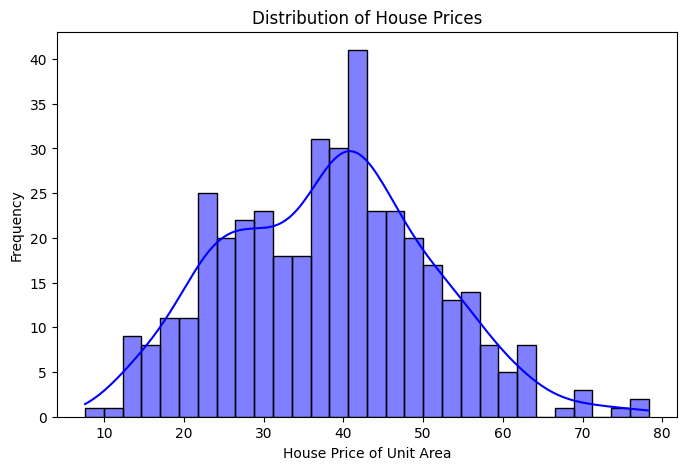

Skewness of house prices: 0.18622645636549132


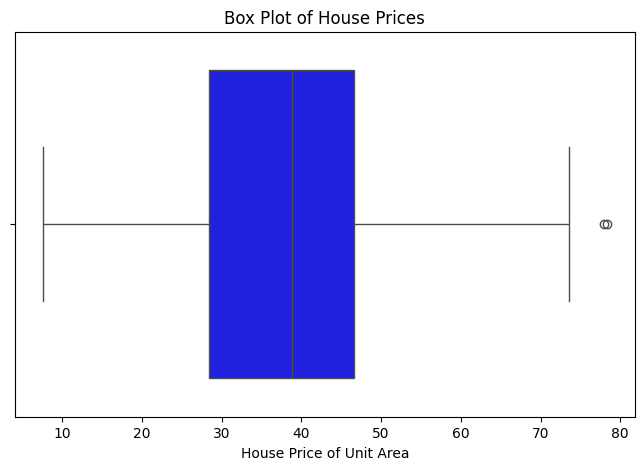

In [29]:
# Plot the distribution of house prices
plt.figure(figsize=(8, 5))
sns.histplot(df['Y house price of unit area'], kde=True, color='blue', bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("House Price of Unit Area")
plt.ylabel("Frequency")
plt.show()
# Check skewness
skewness = df['Y house price of unit area'].skew()
print("Skewness of house prices:", skewness)

# Plot box plot of house prices
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Y house price of unit area'], color='blue')
plt.title("Box Plot of House Prices")
plt.xlabel("House Price of Unit Area")
plt.show()

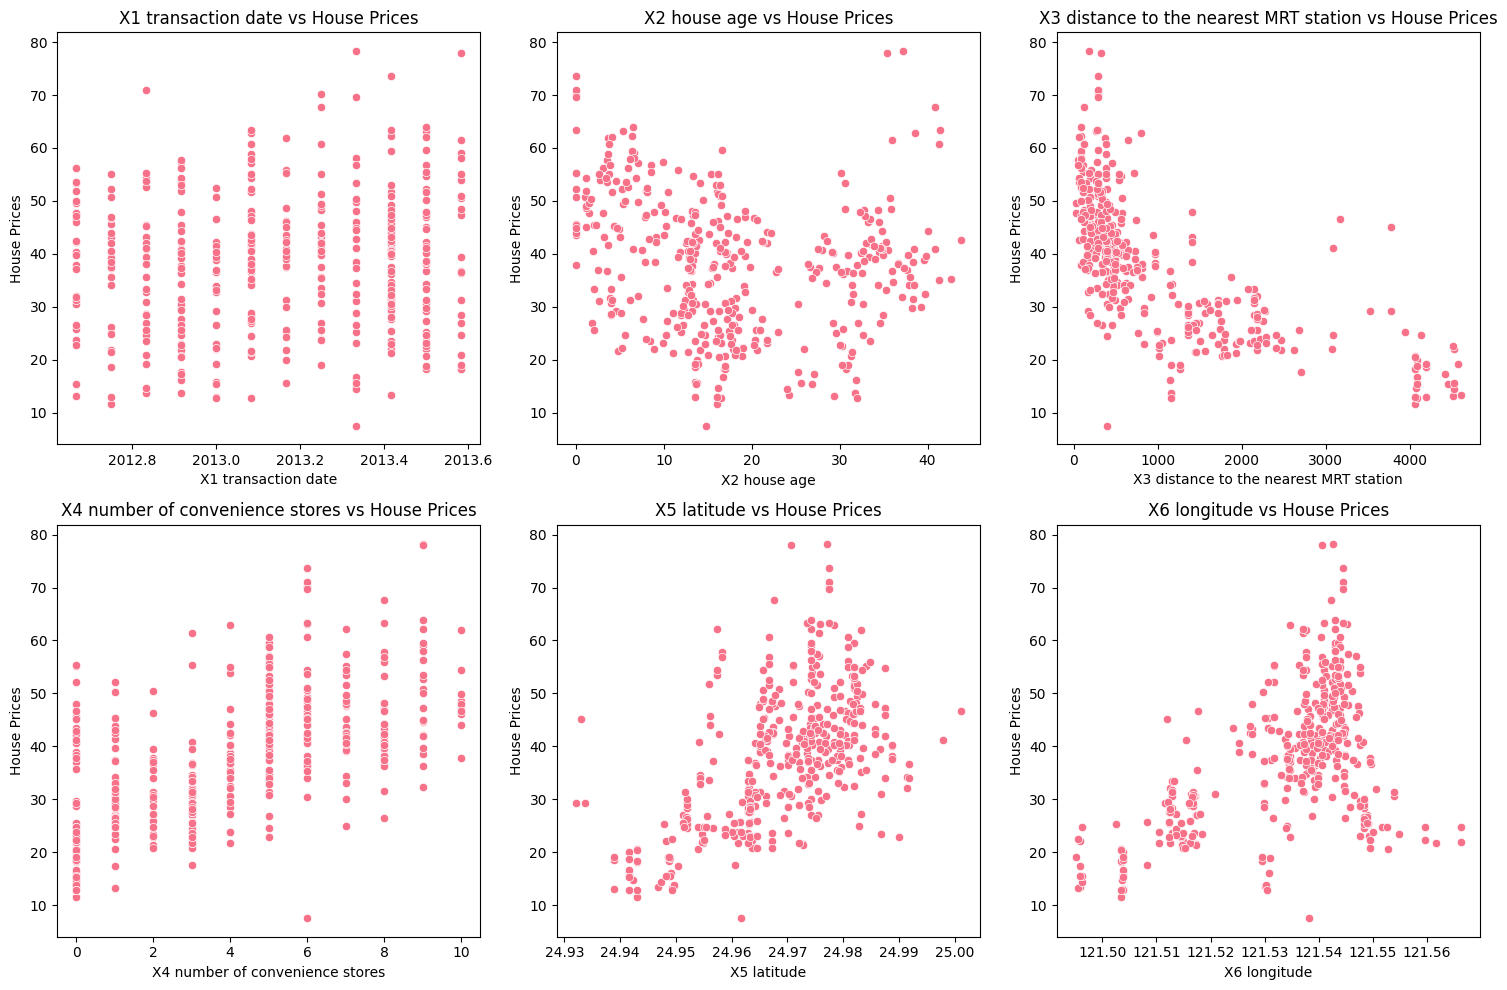

In [30]:
# Plot scatter plots for each feature against house prices
features = ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station',
            'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df, x=feature, y='Y house price of unit area')
    plt.title(f"{feature} vs House Prices")
    plt.xlabel(feature)
    plt.ylabel("House Prices")
plt.tight_layout()
plt.show()


Y house price of unit area                1.000000
X4 number of convenience stores           0.604845
X5 latitude                               0.569685
X6 longitude                              0.522886
X1 transaction date                       0.095572
No                                       -0.042421
X2 house age                             -0.202244
X3 distance to the nearest MRT station   -0.691075
Name: Y house price of unit area, dtype: float64


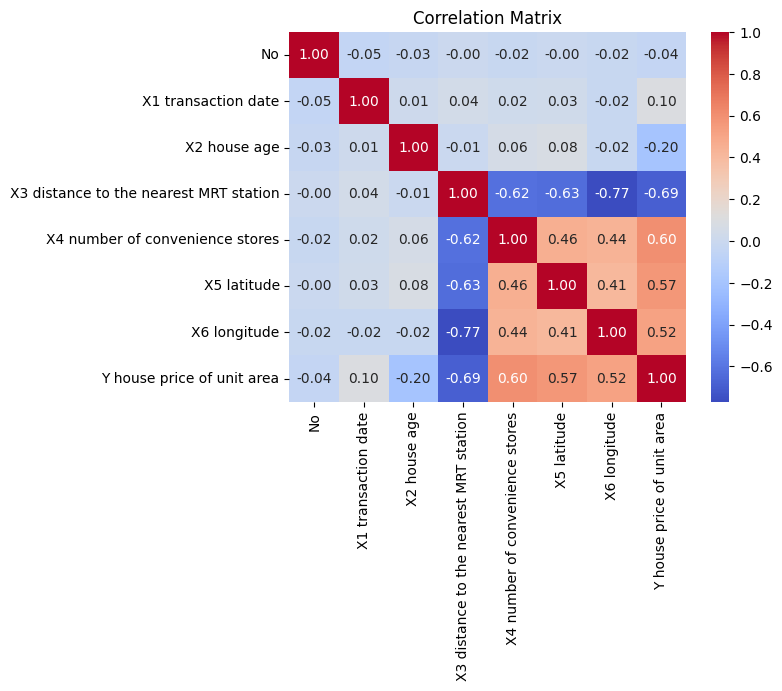

In [ ]:
# Plot correlation matrix
correlations = df.corr(method='pearson')
print(correlations['Y house price of unit area'].sort_values(ascending=False))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


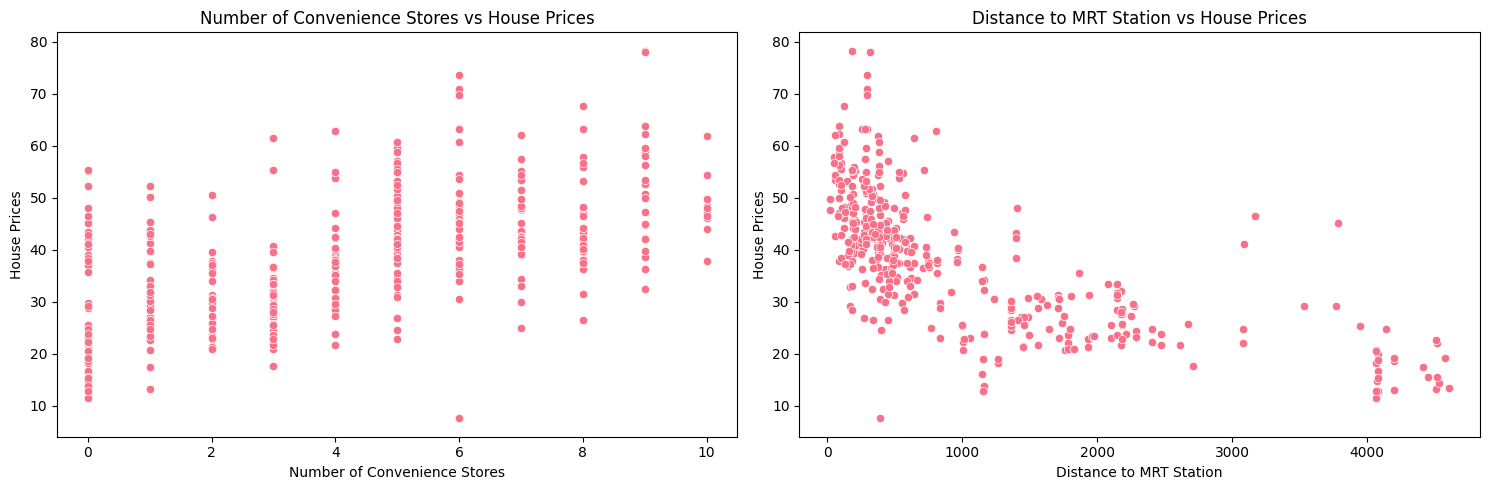

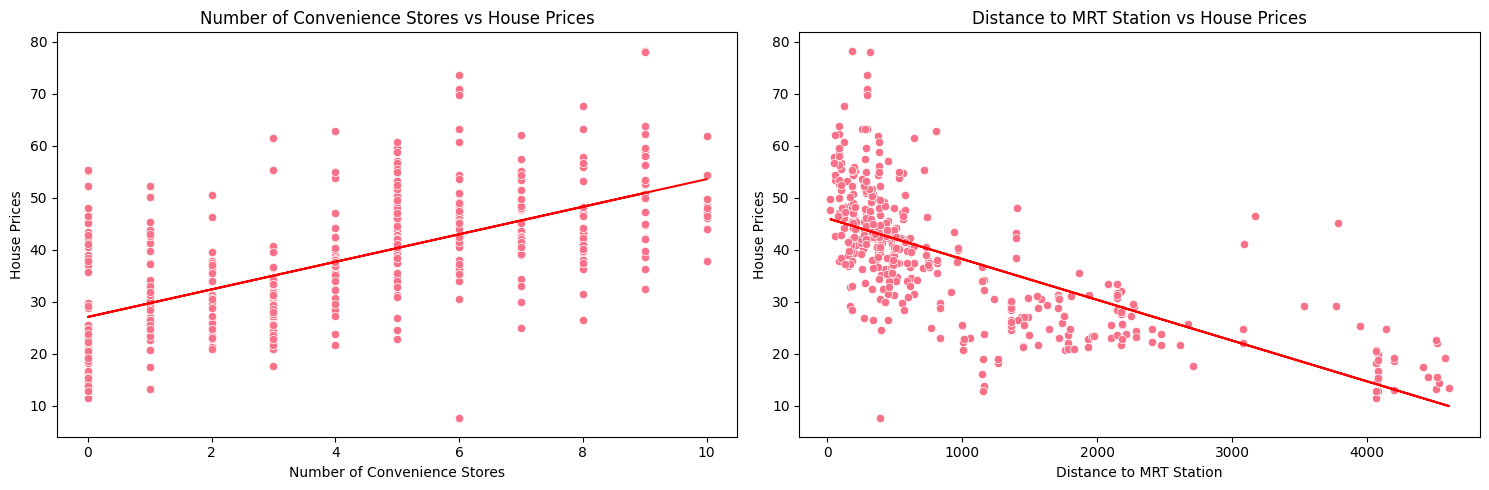

In [31]:
# Scatter plots for features with high correlation
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='X4 number of convenience stores', y='Y house price of unit area')
plt.title("Number of Convenience Stores vs House Prices")
plt.xlabel("Number of Convenience Stores")
plt.ylabel("House Prices")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='X3 distance to the nearest MRT station', y='Y house price of unit area')
plt.title("Distance to MRT Station vs House Prices")

plt.xlabel("Distance to MRT Station")
plt.ylabel("House Prices")
plt.tight_layout()
plt.show()


# fit line to the data
from scipy.stats import linregress

regress = linregress(df['X4 number of convenience stores'], df['Y house price of unit area'])
slope = regress.slope
intercept = regress.intercept

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='X4 number of convenience stores', y='Y house price of unit area')
plt.plot(df['X4 number of convenience stores'], slope * df['X4 number of convenience stores'] + intercept, color='red')
plt.title("Number of Convenience Stores vs House Prices")
plt.xlabel("Number of Convenience Stores")
plt.ylabel("House Prices")

plt.subplot(1, 2, 2)
regress = linregress(df['X3 distance to the nearest MRT station'], df['Y house price of unit area'])
slope = regress.slope
intercept = regress.intercept
sns.scatterplot(data=df, x='X3 distance to the nearest MRT station', y='Y house price of unit area')
plt.plot(df['X3 distance to the nearest MRT station'], slope * df['X3 distance to the nearest MRT station'] + intercept, color='red')
plt.title("Distance to MRT Station vs House Prices")
plt.xlabel("Distance to MRT Station")
plt.ylabel("House Prices")
plt.tight_layout()
plt.show()





### Conclusion 
Based on the feature exploration, we can conclude the following:

1. **House Prices Distribution**: The distribution of house prices shows a slight positive skewness, indicating that most houses are priced below the average, with a few high-priced outliers.

2. **Correlation Analysis**: 
    - The number of convenience stores and the distance to the nearest MRT station are the most effective features affecting house prices.
    - There is a significant negative correlation between house prices and the distance to the nearest MRT station, indicating that houses closer to MRT stations are more expensive.
    - Although, there is a positive correlation between the number of convenience stores and house prices, suggesting that houses with more nearby convenience stores are priced at a higher standpoint.

3. **Scatter Plot Analysis**: 
    - The scatter plots further revalidate the correlation findings, showing clear trend between house prices and the number of convenience stores, as well as the distance to the nearest MRT station.
    - Regression lines of type ( y = mx+b ) fitted to these scatter plots further portray the relationships.

Overall, proximity to facilities such as MRT stations and convenience stores showcases a pivotal role in determining house prices in the dataset.